# Quantum Autoencoder

This notebook demonstrates the package-client quantum autoencoder workflow implemented in `qml.autoencoder`.

The model learns a compression map for structured four-qubit state families using:

- a trainable encoder/decoder ansatz
- a retained latent subsystem
- compression and reconstruction fidelity metrics

The notebook remains a thin client of the package API.

## Tutorial Goals

This tutorial introduces the quantum autoencoder workflow. You will:

- generate a structured family of quantum states
- train an encoder/decoder ansatz
- inspect reconstruction and compression metrics
- review the returned artifacts for plotting and persistence

Use this notebook when learning the unsupervised part of the package.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
from qml.autoencoder import run_quantum_autoencoder

## Run an autoencoder experiment

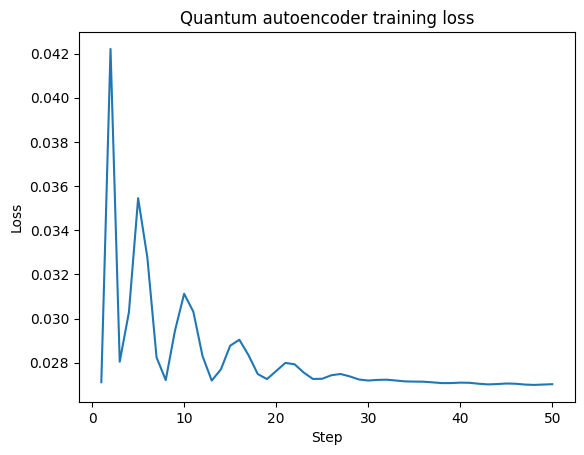

Train compression fidelity: 0.9729841780176779
Test compression fidelity: 0.971444977321234
Train reconstruction fidelity: 0.9729841780176779
Test reconstruction fidelity: 0.9714449773212341
Final loss: 0.027027868067930227


In [3]:
result = run_quantum_autoencoder(
    family="correlated",
    n_samples=120,
    noise=0.02,
    test_size=0.25,
    seed=123,
    n_layers=2,
    latent_qubits=2,
    steps=50,
    step_size=0.1,
    plot=True,
    save=True,
)

print("Train compression fidelity:", result["train_compression_fidelity"])
print("Test compression fidelity:", result["test_compression_fidelity"])
print("Train reconstruction fidelity:", result["train_reconstruction_fidelity"])
print("Test reconstruction fidelity:", result["test_reconstruction_fidelity"])
print("Final loss:", result["final_loss"])

## Inspect learned parameters

In [4]:
print("Parameter tensor shape:", result["params"].shape)
print("Latent qubits:", result["latent_qubits"])
print("Trash qubits:", result["trash_qubits"])

Parameter tensor shape: (2, 4, 2)
Latent qubits: 2
Trash qubits: 2


## Compare state families

In [5]:
for family in ["correlated", "entangled", "hybrid"]:
    res = run_quantum_autoencoder(
        family=family,
        n_samples=120,
        noise=0.02,
        seed=123,
        n_layers=2,
        latent_qubits=2,
        steps=25,
        plot=False,
        save=False,
    )

    print()
    print(family)
    print("  train compression fidelity:", res["train_compression_fidelity"])
    print("  test compression fidelity:", res["test_compression_fidelity"])
    print("  test reconstruction fidelity:", res["test_reconstruction_fidelity"])


correlated
  train compression fidelity: 0.9725666481383045
  test compression fidelity: 0.9710059982389014
  test reconstruction fidelity: 0.9710059982389015



entangled
  train compression fidelity: 0.4378060715512072
  test compression fidelity: 0.4831713546984486
  test reconstruction fidelity: 0.48317135469844863



hybrid
  train compression fidelity: 0.7725086540592571
  test compression fidelity: 0.8327539703789598
  test reconstruction fidelity: 0.8327539703789596
